In [1]:
# ==========================================
# CELL 1: SETUP AND IMPORTS
# ==========================================
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier # Importing the Advanced LightGBM Model
from sklearn.tree import DecisionTreeClassifier # Importing Decision Tree Classifier

import warnings
warnings.filterwarnings('ignore')

print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully!


In [2]:
# ==========================================
# CELL 2: LOAD DATASETS
# ==========================================
print("\n=== Loading Datasets from Google Drive ===")

# Update paths if necessary
base_path = '/content/drive/MyDrive/ML-Assignment/CICIoT23/'
train_path = base_path + '/train.csv'
val_path = base_path + '/validation.csv'
test_path = base_path + '/test.csv'

print("Loading Data (1 Million rows for training)...")
df_train = pd.read_csv(train_path, nrows=1000000)
df_val = pd.read_csv(val_path, nrows=200000)
df_test = pd.read_csv(test_path, nrows=300000)

print(f"Train shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"Test shape: {df_test.shape}\n")


=== Loading Datasets from Google Drive ===
Loading Data (1 Million rows for training)...
Train shape: (1000000, 47)
Validation shape: (200000, 47)
Test shape: (300000, 47)



In [3]:
# ==========================================
# CELL 3: DATA CLEANING & LABEL ENCODING
# ==========================================
print("=== Data Cleaning & Feature Separation ===")

for df in [df_train, df_val, df_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

X_train, y_train = df_train.drop('label', axis=1), df_train['label']
X_val, y_val = df_val.drop('label', axis=1), df_val['label']
X_test, y_test = df_test.drop('label', axis=1), df_test['label']

print("Encoding target labels into numeric values...")
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_train, y_val, y_test]))

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)
print("Encoding complete!")

=== Data Cleaning & Feature Separation ===
Encoding target labels into numeric values...
Encoding complete!


In [4]:
# ==========================================
# CELL 4: FEATURE SCALING
# ==========================================
print("=== Consistent Feature Scaling ===")
scaler = StandardScaler()

print("Fitting scaler on Training data and transforming all sets...")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")

=== Consistent Feature Scaling ===
Fitting scaler on Training data and transforming all sets...
Scaling complete!


In [5]:
# ==========================================
# CELL 5: ADVANCED DECISION TREE TRAINING
# ==========================================
print("=== Training Decision Tree with Advanced Techniques ===")

# ADVANCED TECHNIQUES:
# 1. class_weight='balanced' (Class imbalance handle karnyasaathi)
# 2. max_depth=15 (Overfitting thambavnyasaathi)

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=15,
    min_samples_split=10
)

print("Training the Decision Tree model (This will be very fast)...")
dt_model.fit(X_train_scaled, y_train_encoded)
print("\nTraining complete!")

=== Training Decision Tree with Advanced Techniques ===
Training the Decision Tree model (This will be very fast)...

Training complete!


=== Evaluating on Unseen Test Data ===

          Decision Tree Model Results          
Accuracy : 0.9663  (96.63%)
Macro F1-Score : 0.7638  (76.38%)

Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware       1.00      0.48      0.65        25
          BenignTraffic       0.84      0.26      0.39      6984
       BrowserHijacking       1.00      0.56      0.72        34
       CommandInjection       0.48      0.65      0.55        31
 DDoS-ACK_Fragmentation       1.00      0.98      0.99      1825
        DDoS-HTTP_Flood       0.97      1.00      0.99       170
        DDoS-ICMP_Flood       1.00      1.00      1.00     46157
DDoS-ICMP_Fragmentation       1.00      1.00      1.00      2942
      DDoS-PSHACK_Flood       1.00      1.00      1.00     26448
       DDoS-RSTFINFlood       1.00      1.00      1.00     25982
         DDoS-SYN_Flood       1.00      1.00      1.00     26011
         DDoS-SlowLoris       0.99      0.99 

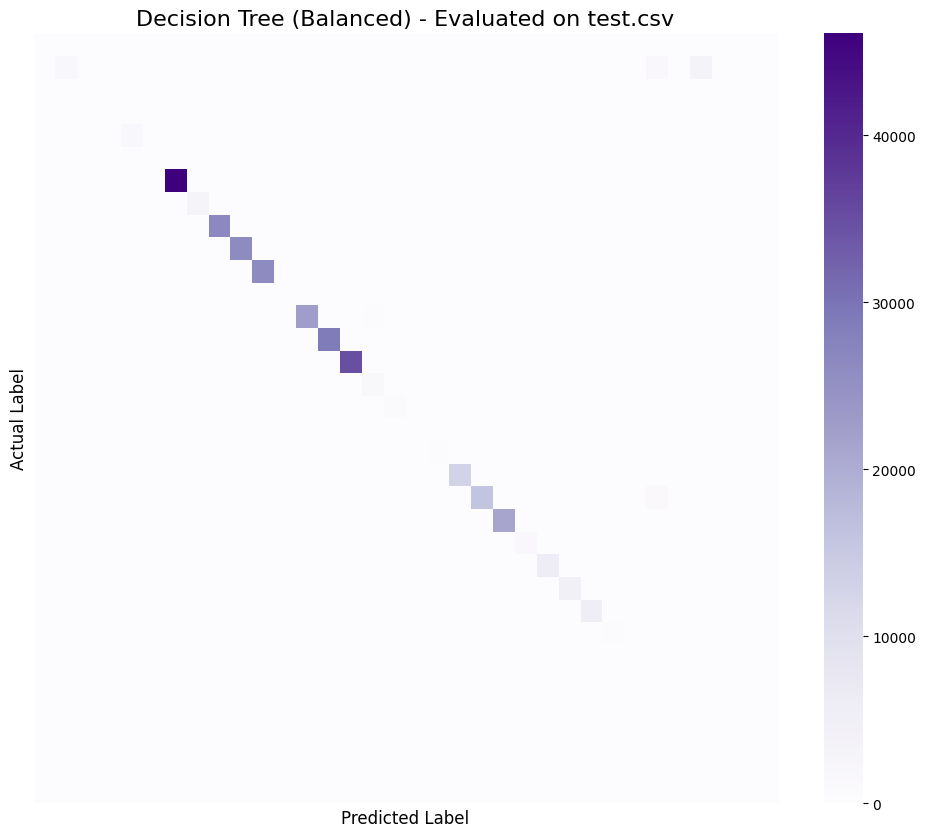

In [6]:
# ==========================================
# CELL 6: EVALUATION AND VISUALIZATION
# ==========================================
print("=== Evaluating on Unseen Test Data ===")
y_pred = dt_model.predict(X_test_scaled)

print("\n" + "="*50)
print("          Decision Tree Model Results          ")
print("="*50)

accuracy = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='macro')

print(f"Accuracy : {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"Macro F1-Score : {f1:.4f}  ({(f1*100):.2f}%)\n")

present_labels = np.unique(np.concatenate((y_test_encoded, y_pred)))
present_target_names = label_encoder.inverse_transform(present_labels)

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, labels=present_labels, target_names=present_target_names))

# Confusion Matrix Heatmap
print("\nGenerating Confusion Matrix Plot...")
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(12, 10))
# Purples color map
sns.heatmap(cm, annot=False, cmap='Purples', xticklabels=False, yticklabels=False)
plt.title('Decision Tree (Balanced) - Evaluated on test.csv', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()